## Imports and Sentiment Tools

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# sentiment tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
from transformers import pipeline

In [116]:
files = [f for f in Path('data_filtered/').iterdir() if f.is_file()]
files.reverse()
songs = pd.read_csv(files[0])

for file in files[1:]:
    data = pd.read_csv(file)
    songs = pd.concat([songs, data])

print(len(songs))
songs.head(3)

259458


,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics
0,256,3iBgrkexCzVuPy4O9vx7Mf,Glue Song,Glue Song,"[""beabadoobee""]",0.620,0.409,1,-10.146,1,...,135067,"i've never known someone like you, ooh tangled...",2023,Pop,81,6764580,80.000000,"[""35l9BRT7MXmM8bv2WDQiyB""]","[""bedroom pop""]",True
1,646,60SvhHtwefT0e2G7i7kOH3,New Gold (feat. Tame Impala and Bootie Brown),Cracker Island,"[""Gorillaz"", ""Tame Impala"", ""Bootie Brown""]",0.695,0.923,1,-3.930,0,...,215150,but in the magic cove there's a pretty one i a...,2023,Rock,77,24787609,78.333333,"[""3AA28KZvwAUcZuOKwyblJQ"", ""5INjqkS1o8h1imAzPq...","[""indie"", ""neo-psychedelic""]",True
2,891,0FA4wrjDJvJTTU8AepZTup,Watch This - ARIZONATEARS Pluggnb Remix,Watch This (ARIZONATEARS Pluggnb Remix),"[""Lil Uzi Vert"", ""sped up nightcore"", ""ARIZONA...",0.686,0.897,11,-7.180,0,...,163139,jump in a whip that you've never seen (yeah) i...,2023,Hip-Hop,75,19685914,71.333333,"[""4O15NlyKLIASxsJ0PrXPfz"", ""0M2CO5ijP35MDhNwvp...","[""melodic rap"", ""nightcore""]",True


In [155]:
def clean_lyrics(lyrics):
    cleaned = re.sub(r'\[.*?\]', '', lyrics)
    cleaned = re.sub(r'\d{1,2}:\d{2}(\.\d+)?', '', cleaned)
    cleaned = cleaned.strip()
    return cleaned

songs['lyrics'] = songs['lyrics'].apply(clean_lyrics)
songs = songs[songs['is_valid_lyrics'] == True].reset_index(drop=True)
print(f"Tracks entering sentiment pipeline: {len(songs):,}")

Tracks entering sentiment pipeline: 259,458


In [ ]:
songs.dtypes.rename('dtypes').to_frame()

---
## Sentiment Tool Testing

- VADER
    - baseline/primary sentiment tool that auto gives continuous score [-1, 1]
- AFINN
    - lexicon-based sentiment tool similar to VADER but produces summed/averaged across text, NOT same range as VADER
- siebert/sentiment-roberta-large-english
    - classification model (can be used as directional/confidence check for VADER)

In [123]:
vader = SentimentIntensityAnalyzer()
afinn = Afinn()

i = 10
print(f'VALENCE: {songs['valence'].iloc[i]}')
test_lyric = songs['lyrics'].iloc[i]
test_lyric

VALENCE: 0.0726


"do you dream alone under the moon? is it brighter, brighter when i'm with you? is the afterglow strong enough? to light this fire, fire back in us? uh-oh mixed emotions hearts still open though we're far apart i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are are you wide awake counting the stars? or just lying, lying in the dark? uh-oh mixed emotions hearts still open though we're far apart i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are i wanna be where you are i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are i get this feeling i wanna be where you are i wanna be where you are i wanna be where you are"

In [124]:
vader_score = vader.polarity_scores(test_lyric)['compound']
vader_score

0.9163

In [125]:
def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

afinn_score = afinn_normalized_matched(test_lyric, afinn)
afinn_score

0.2727272727272727

In [126]:
sentiment_analysis = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english", device=-1)
sentiment_analysis(
    test_lyric, 
    truncation=True,
    max_length=512
)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 32550.58it/s]


[{'label': 'POSITIVE', 'score': 0.9979167580604553}]

---
## Lyrical Sentiment Feature/s

In [145]:
sample_songs = songs.sample(n=1000).copy()

In [146]:
vader = SentimentIntensityAnalyzer()

sample_songs['vader_compound'] = sample_songs['lyrics'].apply(
    lambda x: vader.polarity_scores(x)['compound']
)
sample_songs[['valence', 'vader_compound']].describe()

,valence,vader_compound
count,1000.000000,1000.000000
mean,0.423270,0.179782
std,0.243881,0.859138
min,0.027400,-0.999500
25%,0.217750,-0.875025
50%,0.392500,0.716100
75%,0.619250,0.983450
max,0.972000,0.999900


In [147]:
afinn = Afinn()

def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

sample_songs['afinn_raw'] = sample_songs['lyrics'].apply(lambda x: afinn_normalized_matched(x, afinn))

# rescale to [-1, 1] for rough comparability with VADER
min_val, max_val = sample_songs['afinn_raw'].min(), sample_songs['afinn_raw'].max()
sample_songs['afinn_rescaled'] = 2 * (sample_songs['afinn_raw'] - min_val) / (max_val - min_val) - 1
sample_songs[['valence', 'afinn_rescaled']].describe()

,valence,afinn_rescaled
count,1000.000000,1000.000000
mean,0.423270,-0.224181
std,0.243881,0.211343
min,0.027400,-1.000000
25%,0.217750,-0.366825
50%,0.392500,-0.236341
75%,0.619250,-0.083895
max,0.972000,1.000000


In [148]:
from tqdm import tqdm
tqdm.pandas()

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="siebert/sentiment-roberta-large-english",
    device=-1,
    truncation=True,
    max_length=512
)

def get_signed_roberta_score(text):
    result = sentiment_pipe(text)[0]
    return result['score'] if result['label'] == 'POSITIVE' else -result['score']

# NOTE: run on a sample first if the full dataset is large — this is CPU and slow
sample_for_roberta = sample_songs.sample(n=(len(sample_songs) // 10), random_state=42).copy()
sample_for_roberta['roberta_signed'] = sample_for_roberta['lyrics'].progress_apply(get_signed_roberta_score)
sample_for_roberta['roberta_signed'].describe()

100%|██████████| 100/100 [01:08<00:00,  1.47it/s]


count    100.000000
mean       0.293091
std        0.950188
min       -0.999295
25%       -0.992333
50%        0.989585
75%        0.997596
max        0.998870
Name: roberta_signed, dtype: float64

In [152]:
from scipy.stats import pearsonr, spearmanr

merged_check = sample_for_roberta[['vader_compound', 'afinn_rescaled', 'roberta_signed']].dropna()

pairs = [('vader_compound', 'afinn_rescaled'), 
         ('vader_compound', 'roberta_signed'), 
         ('afinn_rescaled', 'roberta_signed')]

for a, b in pairs:
    r, _ = pearsonr(merged_check[a], merged_check[b])
    rho, _ = spearmanr(merged_check[a], merged_check[b])
    print(f"{a} vs {b}: Pearson r={r:.3f}, Spearman rho={rho:.3f}")

vader_compound vs afinn_rescaled: Pearson r=0.691, Spearman rho=0.754
vader_compound vs roberta_signed: Pearson r=0.198, Spearman rho=0.459
afinn_rescaled vs roberta_signed: Pearson r=0.172, Spearman rho=0.328


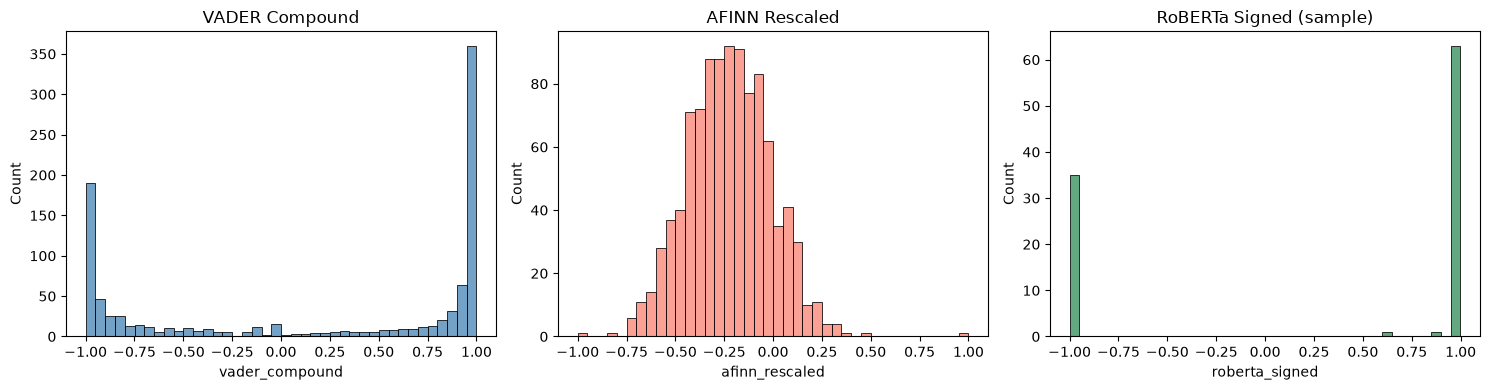

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(sample_songs['vader_compound'], ax=axes[0], bins=40, color='steelblue')
axes[0].set_title('VADER Compound')

sns.histplot(sample_songs['afinn_rescaled'], ax=axes[1], bins=40, color='salmon')
axes[1].set_title('AFINN Rescaled')

sns.histplot(sample_for_roberta['roberta_signed'], ax=axes[2], bins=40, color='seagreen')
axes[2].set_title('RoBERTa Signed (sample)')

plt.tight_layout()
plt.show()